<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">

# **Análisis de Series de Tiempo II**
# **Clase 8, Time Series RAG con embeddings de Chronos**

En vez de representar cada ventana con su z-score, la pasamos por el encoder de Chronos-Bolt y usamos ese vector.



**Dataset real:** temperaturas mínimas diarias en Melbourne, Australia (1981-1990), 3650 observaciones.

Importamos lo necesario

In [ ]:
!pip install -q "chronos-forecasting>=2.0"

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

Cargamos el dataset real. Usaremos un dataset clásico y público de series de tiempo, el de la temperatura mínima diaria en Melbourne.

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=["Date"])
df = df.rename(columns={"Temp": "temperatura"})

print(f"Total de observaciones: {len(df)}")
df.head()

Total de observaciones: 3650


,Date,temperatura
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


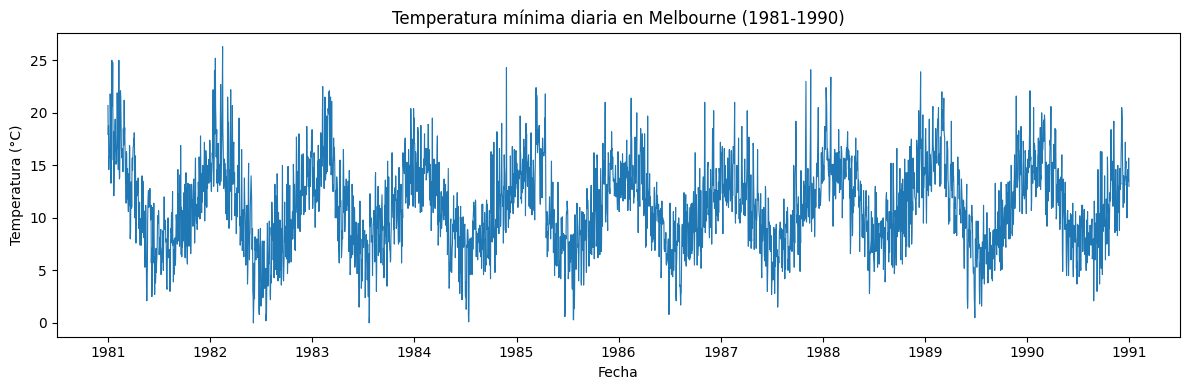

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["temperatura"], linewidth=0.8)
plt.title("Temperatura mínima diaria en Melbourne (1981-1990)")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()

## A) Construcción de la Base de Conocimiento de Ventanas Históricas

* En un RAG de texto, la base de conocimiento son documentos o párrafos.
+ En un RAG de series de tiempo, la base de conocimiento son ventanas (fragmentos) de la serie histórica, cada una acompañada de lo que ocurrió justo después.

- WINDOW: cuántos días de historia miramos para describir una "situación" (el contexto).
- HORIZON: cuántos días hacia adelante queremos pronosticar (lo que buscamos "recuperar" como respuesta).

Cada ventana pasada queda guardada junto con su "continuación real", como si fuera
un par (pregunta, respuesta) en una base de RAG de texto.

In [ ]:
WINDOW = 30  # días de contexto que describen una "situación"
HORIZON = 7  # días que queremos pronosticar hacia adelante

serie = df["temperatura"].values

def crear_ventanas(serie, window, horizon):
    contextos, continuaciones = [], []
    for i in range(len(serie) - window - horizon + 1):
        contextos.append(serie[i:i+window])
        continuaciones.append(serie[i+window:i+window+horizon])
    return np.array(contextos), np.array(continuaciones)

contextos, continuaciones = crear_ventanas(serie, WINDOW, HORIZON)

print(f"Ventanas construidas: {contextos.shape[0]}")
print(f"Cada contexto tiene {contextos.shape[1]} días, cada continuación {continuaciones.shape[1]} días")

Ventanas construidas: 3614
Cada contexto tiene 30 días, cada continuación 7 días


* Guardamos, para cada ventana, el índice del último día que la ventana necesita conocer.
* La ventana i usa datos hasta la posición (i + WINDOW + HORIZON - 1): su continuación incluida.
* Este vector es lo que nos va a permitir filtrar el índice por tiempo en la sección C.

In [ ]:
fin_ventana = np.arange(len(contextos)) + WINDOW + HORIZON - 1

## B) Embeddings de cada ventana (con Chronos-Bolt)

* Antes: convertíamos cada ventana en su z-score (30 números).
* Ahora: la pasamos por el encoder de Chronos-Bolt, un modelo preentrenado sobre millones de series.
  Es el equivalente a usar un modelo de lenguaje para vectorizar documentos en un RAG de texto.

Igual seguimos necesitando normalizar_ventana: el **generador** (sección D) la usa para llevar las
continuaciones de los análogos a la escala de la ventana actual. Lo que cambia es con qué buscamos,
no cómo combinamos lo que encontramos.

In [ ]:
def normalizar_ventana(ventana):
    promedio = ventana.mean()
    desviacion = ventana.std() + 1e-8
    ventana_normalizada = (ventana - promedio) / desviacion
    return ventana_normalizada, promedio, desviacion

`pipeline.embed(ventanas)` corre el encoder **sin pronosticar nada** y devuelve un vector **por parche**:
`(batch, n_tokens, d_model)`. Como el RAG necesita **un vector por ventana**, promediamos los tokens
(mean pooling), igual que se hace con BERT para representar una oración.


- Chronos **normaliza internamente** cada serie (te devuelve `loc_scale` aparte), así que el embedding ya
  describe la forma y no el nivel: el mismo objetivo que perseguíamos con el z-score, pero aprendido.
- Bolt usa parches de 16 pasos, así que una ventana de 30 días son apenas 2 parches. Si queremos que el
  embedding tenga de dónde sacar estructura, subimos `WINDOW` a 64–128.

In [ ]:
from chronos import BaseChronosPipeline

DEV = "cuda" if torch.cuda.is_available() else "cpu"
# bolt_small va bien en CPU. Alternativas: chronos-bolt-tiny (más rápido), chronos-bolt-base (mejor).
pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-bolt-small", device_map=DEV)

@torch.no_grad()
def embeddings_chronos(ventanas, batch=256):
    #Convierte cada ventana en UN vector usando el encoder de Chronos.
    salida = []
    for i in range(0, len(ventanas), batch):
        lote = torch.tensor(ventanas[i:i+batch], dtype=torch.float32)
        emb, loc_scale = pipeline.embed(lote)  # (B, n_tokens, d_model)
        salida.append(emb.mean(dim=1).float().cpu().numpy())  # mean pooling -> (B, d_model)
    return np.vstack(salida)

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

In [ ]:
print(f"Calculando embeddings de {len(contextos)} ventanas en {DEV}")

Calculando embeddings de 3614 ventanas en cuda


In [ ]:
base_embeddings = embeddings_chronos(contextos)
print("Forma de la base de embeddings:", base_embeddings.shape)

# Guardamos también la versión z-score para poder comparar al final (sección G)
base_embeddings_zscore = np.array([normalizar_ventana(v)[0] for v in contextos])

Forma de la base de embeddings: (3614, 512)


## C) Retriever: buscar las situaciones históricas más parecidas

Simplemente le pasamos el vector de Chronos.

* Dada una ventana nueva (la situación actual), calculamos qué tan parecida es su forma a cada ventana guardada en la base, usando similitud coseno. Nos quedamos con las k más parecidas.
* El corte es la posición en la serie que representa "hoy". Solo se pueden recuperar ventanas cuya continuación terminó antes de ese corte.
* El embedding consulta nos permite usar otra representación. Si es None, usa el z-score.

In [ ]:
def recuperar_analogos(ventana_consulta, base_embeddings, k=5, corte=None,
                       fin_ventana=fin_ventana, embedding_consulta=None):

    if embedding_consulta is None:
        consulta_normalizada, _, _ = normalizar_ventana(ventana_consulta)
    else:
        consulta_normalizada = embedding_consulta

    normas_base = np.linalg.norm(base_embeddings, axis=1)
    norma_consulta = np.linalg.norm(consulta_normalizada)
    similitudes = (base_embeddings @ consulta_normalizada) / (normas_base * norma_consulta + 1e-8)

    orden = np.argsort(-similitudes)  # de más a menos parecido

    if corte is not None:
        # Nos quedamos solo con ventanas del pasado (continuación incluida).
        # Esto también resuelve el solapamiento, porque una ventana que se solapa con la
        # consulta necesariamente termina después del corte.
        permitidas = fin_ventana < corte
        orden = orden[permitidas[orden]]

    mejores_indices = orden[:k]
    return mejores_indices, similitudes

## D) Generator: construir el pronóstico a partir de lo recuperado

Los análogos se recuperaron con Chronos, pero se combinan igual que antes.

* En un RAG de texto, el modelo generador redacta una respuesta usando los documentos recuperados como contexto.
* Nuestro generador es más simple pero sigue el mismo principio: promediamos lo que pasó después en cada una de las situaciones históricas más parecidas.
* Esto se llama pronóstico por análogos: en vez de asumir una fórmula matemática fija, dejamos que la historia (los datos recuperados) "vote" cuál es el futuro más probable.

La siguiente función combina las continuaciones de los análogos en un pronóstico (mediana + cuantiles)

In [ ]:
def generar_pronostico(indices_analogos, similitudes, ventana_actual,
                       cuantiles=(0.1, 0.5, 0.9), ponderar=True):
    _, mu_consulta, sigma_consulta = normalizar_ventana(ventana_actual)

    # Cada continuación se normaliza con los estadísticos de su propio contexto
    continuaciones_norm = np.array([
        (continuaciones[i] - contextos[i].mean()) / (contextos[i].std() + 1e-8)
        for i in indices_analogos
    ])

    # Los más parecidos pesan más (similitud elevada a 3 = más selectivo)
    if ponderar:
        pesos = np.clip(similitudes[indices_analogos], 0, None) ** 3
        pesos = pesos / pesos.sum() if pesos.sum() > 0 else np.ones(len(indices_analogos)) / len(indices_analogos)
    else:
        pesos = np.ones(len(indices_analogos)) / len(indices_analogos)

    # Al final se devuelve todo a la escala de la ventana actual
    media_norm = (continuaciones_norm * pesos[:, None]).sum(axis=0)
    pronostico = media_norm * sigma_consulta + mu_consulta

    # Cuantiles empíricos sobre los K análogos (sin supuesto gaussiano)
    q = {c: np.quantile(continuaciones_norm, c, axis=0) * sigma_consulta + mu_consulta
         for c in cuantiles}
    return pronostico, q

* Tomamos como "situación actual" los últimos 30 dias disponibles antes del tramo final, y comparamos el pronóstico contra lo que realmente ocurrió (para poder evaluar).

* Única diferencia respecto del notebook anterior: además de la ventana, le pasamos su **embedding de
Chronos** como `embedding_consulta`.

In [ ]:
posicion_consulta = len(serie) - WINDOW - HORIZON
ventana_actual = serie[posicion_consulta : posicion_consulta + WINDOW]
futuro_real   = serie[posicion_consulta + WINDOW : posicion_consulta + WINDOW + HORIZON]

K = 5
CORTE = posicion_consulta + WINDOW # "hoy", el último dato que el sistema conoce

indices_analogos, similitudes = recuperar_analogos(
    ventana_actual, base_embeddings, k=K, corte=CORTE,
    embedding_consulta=base_embeddings[posicion_consulta],   # el vector de Chronos de esta ventana
)

print("Índices de las situaciones históricas más parecidas:", indices_analogos)
print("Similitud de cada una:", [round(similitudes[i], 3) for i in indices_analogos])
print("Fechas de esos análogos:",
      [str(df.Date.iloc[i + WINDOW - 1].date()) for i in indices_analogos])

Índices de las situaciones históricas más parecidas: [3284 2228 2227 2229 3026]
Similitud de cada una: [np.float32(0.893), np.float32(0.887), np.float32(0.872), np.float32(0.855), np.float32(0.845)]
Fechas de esos análogos: ['1990-01-29', '1987-03-09', '1987-03-08', '1987-03-10', '1989-05-16']


El generador combina lo que pasó después en cada situación análoga

In [ ]:
pronostico_rag, cuantiles_rag = generar_pronostico(indices_analogos, similitudes, ventana_actual)

print("Pronóstico (RAG con embeddings de Chronos):", np.round(pronostico_rag, 2))
print("Valor real                                :", np.round(futuro_real, 2))

Pronóstico (RAG con embeddings de Chronos): [11.64 12.71 11.75 11.   10.89 12.55 13.63]
Valor real                                : [12.9 14.6 14.  13.6 13.5 15.7 13. ]


## E) Visualizar: contexto, análogos recuperados y pronóstico

* mostramos la situación actual (línea sólida)
* las situaciones históricas parecidas que el sistema "recuperó" (líneas de fondo)
* el pronóstico que resulta de combinarlas
* el intervalo de predicción que surge de la dispersión entre los análogos

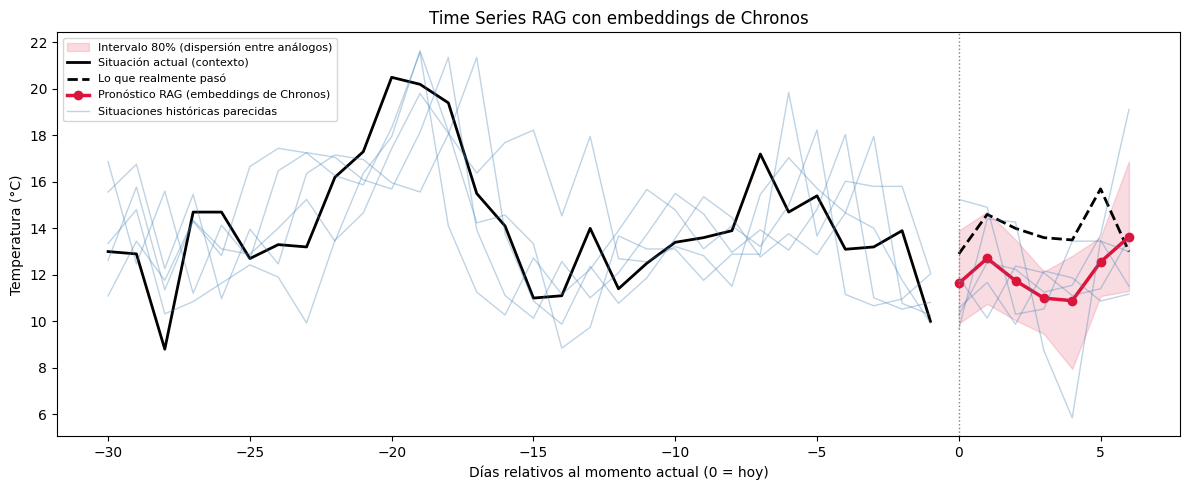

In [ ]:
plt.figure(figsize=(12, 5))
eje_contexto = np.arange(-WINDOW, 0)
eje_futuro   = np.arange(0, HORIZON)

# Intervalo empírico
plt.fill_between(eje_futuro, cuantiles_rag[0.1], cuantiles_rag[0.9], color="crimson", alpha=0.15,
                 label="Intervalo 80% (dispersión entre análogos)")
# Ventana actual (el query)
plt.plot(eje_contexto, ventana_actual, color="black", linewidth=2, label="Situación actual (contexto)")
# Futuro real
plt.plot(eje_futuro, futuro_real, color="black", linewidth=2, linestyle="--", label="Lo que realmente pasó")
# Pronóstico RAG
plt.plot(eje_futuro, pronostico_rag, color="crimson", linewidth=2.5, marker="o",
         label="Pronóstico RAG (embeddings de Chronos)")

# Análogos recuperados (contexto + su continuación real), reescalados a la escala de la consulta
_, mu_q, sigma_q = normalizar_ventana(ventana_actual)
for i, idx in enumerate(indices_analogos):
    contexto_analogo = contextos[idx]
    continuacion_analoga = continuaciones[idx]
    analogo_normalizado, _, _ = normalizar_ventana(contexto_analogo)
    continuacion_normalizada = (continuacion_analoga - contexto_analogo.mean()) / (contexto_analogo.std() + 1e-8)
    analogo_reescalado = analogo_normalizado * sigma_q + mu_q
    continuacion_reescalada = continuacion_normalizada * sigma_q + mu_q

    etiqueta = "Situaciones históricas parecidas" if i == 0 else None
    plt.plot(eje_contexto, analogo_reescalado, color="steelblue", alpha=0.35, linewidth=1, label=etiqueta)
    plt.plot(eje_futuro, continuacion_reescalada, color="steelblue", alpha=0.35, linewidth=1)

plt.axvline(0, color="gray", linestyle=":", linewidth=1)
plt.title("Time Series RAG con embeddings de Chronos")
plt.xlabel("Días relativos al momento actual (0 = hoy)")
plt.ylabel("Temperatura (°C)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## F) Evaluar el pronóstico y comparar contra un baseline simple

* Para saber si el RAG realmente sirve, lo comparamos contra el Naive Baseline.
* Usamos el error absoluto medio (MAE)

In [ ]:
def mae(pred, real):
    return np.mean(np.abs(np.array(pred) - np.array(real)))

pronostico_naive = np.repeat(ventana_actual[-1], HORIZON)

print(f"MAE RAG con Chronos (k={K})        : {mae(pronostico_rag, futuro_real):.2f}")
print(f"MAE baseline ingenuo (último valor): {mae(pronostico_naive, futuro_real):.2f}")

MAE RAG con Chronos (k=5)        : 2.06
MAE baseline ingenuo (último valor): 3.90


## G) ¿Los embeddings de Chronos recuperan mejor que el z-score?

* Un solo pronóstico no prueba nada, así que repetimos el experimento en ~120 cortes del último año.
Las dos representaciones usan el mismo retriever, el mismo generador y los mismos cortes: lo único
distinto es la matriz de embeddings.

* Agregamos también la **climatología** (promedio histórico de ese día del año, solo con datos previos al
corte), que en datos de temperatura es el rival serio a vencer.

In [ ]:
dia_del_anio = df["Date"].dt.dayofyear.values

def pronosticar_rag(pos, E, k=25):
    """Corre el flujo completo (C + D) con la representación E, en la posición pos."""
    ventana = serie[pos : pos + WINDOW]
    idx, sim = recuperar_analogos(ventana, E, k=k, corte=pos + WINDOW, embedding_consulta=E[pos])
    if len(idx) == 0:
        return np.repeat(ventana[-1], HORIZON)
    pron, _ = generar_pronostico(idx, sim, ventana)
    return pron

def pronosticar_climatologia(pos):
    corte = pos + WINDOW
    pasado, dias = serie[:corte], dia_del_anio[:corte]
    return np.array([pasado[dias == dia_del_anio[corte + j]].mean()
                     if (dias == dia_del_anio[corte + j]).any() else pasado.mean()
                     for j in range(HORIZON)])

cortes = list(range(len(serie) - 365 - WINDOW - HORIZON, len(serie) - WINDOW - HORIZON, 3))

resultados = {}
for nombre, fn in [
    ("RAG · embeddings Chronos", lambda p: pronosticar_rag(p, base_embeddings)),
    ("RAG · z-score",            lambda p: pronosticar_rag(p, base_embeddings_zscore)),
    ("Climatología",             pronosticar_climatologia),
    ("Naive (último valor)",     lambda p: np.repeat(serie[p + WINDOW - 1], HORIZON)),
]:
    resultados[nombre] = np.mean([mae(fn(p), serie[p+WINDOW:p+WINDOW+HORIZON]) for p in cortes])

print(f"{len(cortes)} cortes evaluados\n")
print(pd.Series(resultados, name="MAE (°C)").sort_values().round(3).to_string())

122 cortes evaluados

RAG · z-score               2.043
RAG · embeddings Chronos    2.088
Climatología                2.128
Naive (último valor)        2.785


**Ventajas de este enfoque:**
- Es interpretable: siempre puedes mostrar *qué* situaciones históricas motivaron el pronóstico.
- No requiere entrenar un modelo: el encoder viene preentrenado y el índice se arma una sola vez.
- Se adapta bien cuando el pasado tiende a repetirse (estacionalidad, patrones climáticos, ciclos de demanda).
- El embedding transfiere conocimiento de millones de series: es lo que permite recuperar análogos
  razonables en series nuevas o de otra escala.

**Limitaciones:**
- Si ocurre algo nunca antes visto, no habrá buenos análogos que recuperar.
- Con ventanas cortas (2 parches para Bolt) el embedding tiene poco que representar y el z-score crudo es
  un rival durísimo. Los embeddings preentrenados van bien con muchas series heterogéneas y ventanas largas.
- El checkpoint es un artefacto más que versionar:¡, si lo cambiamos, hay que recalcular todo el índice
- El embedding no nos protege del leakage: el filtro point-in-time de la sección C sigue siendo importante.